# Previsão de Produtividade de Safra — Modelo de Regressão

**Contexto de negócio (fictício, para fins didáticos):** uma cooperativa agrícola quer estimar,
antes da colheita, a produtividade esperada (toneladas/hectare) de cada talhão a partir de
variáveis de clima, solo e manejo já conhecidas durante o ciclo da safra. O objetivo é apoiar
**planejamento logístico** (armazenagem, transporte) e **decisões de crédito agrícola** —
portanto o foco principal é **predição** (acurácia em dados novos), mas a cooperativa também
quer entender **quais fatores mais influenciam a produtividade**, então a interpretabilidade do
modelo final importa tanto quanto a métrica.

- **Target:** `produtividade_ton_ha` (toneladas por hectare) — variável contínua.
- **Uso:** predição, com componente de inferência/explicabilidade para orientar recomendações agronômicas.
- **Dados:** base sintética `base_sintetica_previsao_produtividade_safra.csv`, gerada para simular
  um cenário agronômico realista (clima, solo, manejo) com relações não lineares e os mesmos
  problemas de qualidade que apareceriam em dados de campo reais (nulos, outliers, duplicatas,
  inconsistências de categoria).

**Como rodar (importante):** use o menu **Ambiente de execução → Executar tudo** (Colab) ou
**Run All** (Jupyter/VS Code), em vez de rodar célula por célula manualmente. Várias células mais
à frente dependem de variáveis criadas em células anteriores (ex: a tabela de comparação de
modelos, o modelo escolhido, os resíduos) — se uma célula for pulada sem querer no meio do
caminho, as células seguintes vão falhar com `NameError` mesmo estando com o código correto.
"Executar tudo" evita esse problema porque roda todas as células em ordem, sem pular nenhuma.

Este notebook usa o stack padrão de ciência de dados em Python (pandas, numpy, matplotlib,
seaborn, scikit-learn, scipy, statsmodels, shap, joblib — veja `requirements.txt`). Instale as
dependências (`pip install -r requirements.txt`) antes de executar, ou rode direto no Google
Colab, que já tem a maior parte pré-instalada.

Segue o pipeline completo de regressão: EDA → pré-processamento → split → escalonamento →
modelos base → validação cruzada → tuning → diagnóstico → interpretabilidade → valor de negócio → entregáveis.


## Fase 1 — Carregamento e Inspeção Inicial

Antes de qualquer modelagem, precisamos entender a forma bruta dos dados: quantas linhas e
colunas temos, que tipo cada coluna tem, e se a variável target é de fato uma contínua numérica
compatível com regressão.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, probplot

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, RandomizedSearchCV,
    learning_curve, TimeSeriesSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)


In [ ]:
# Este notebook foi pensado para rodar de dentro da pasta `notebook/`, com o
# CSV em `../data/...` (é assim que fica ao abrir a pasta inteira do projeto,
# por exemplo no VS Code). O Google Colab não tem essa estrutura de pastas por
# padrão -- o código abaixo detecta o ambiente e resolve o caminho automaticamente,
# incluindo um fallback de upload manual caso o arquivo não seja encontrado em
# nenhum lugar esperado.

import os

NOME_ARQUIVO = "/content/base_sintetica_previsao_produtividade_safra_v2.csv"

def rodando_no_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def resolver_data_path():
    candidatos = [
        f"../data/{NOME_ARQUIVO}",  # projeto completo (VS Code, Jupyter local)
        f"data/{NOME_ARQUIVO}",     # notebook e pasta data/ no mesmo nível
        NOME_ARQUIVO,               # CSV solto na mesma pasta do notebook
        f"/content/{NOME_ARQUIVO}", # upload direto na raiz do Colab
    ]
    for caminho in candidatos:
        if os.path.exists(caminho):
            return caminho

    if rodando_no_colab():
        print(
            f"Não encontrei '{NOME_ARQUIVO}' em nenhum caminho esperado. "
            "Selecione o arquivo CSV na janela de upload abaixo."
        )
        from google.colab import files
        enviados = files.upload()
        if NOME_ARQUIVO in enviados:
            return NOME_ARQUIVO
        # usa o primeiro CSV enviado, caso o nome esteja diferente
        for nome in enviados:
            if nome.lower().endswith(".csv"):
                return nome
        raise FileNotFoundError("Nenhum CSV foi enviado.")

    raise FileNotFoundError(
        f"Não encontrei '{NOME_ARQUIVO}'. Verifique se a pasta 'data/' está "
        "no lugar certo em relação a este notebook (veja o topo do notebook)."
    )


DATA_PATH = resolver_data_path()
print(f"Carregando dados de: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Carregando dados de: /content/base_sintetica_previsao_produtividade_safra_v2.csv
Shape: 2015 linhas x 15 colunas


,id_talhao,ano_safra,regiao,cultivar,tipo_solo,irrigacao,area_plantada_ha,chuva_mm,temperatura_media_c,horas_sol_dia,ph_solo,fertilizante_kg_ha,indice_pragas,densidade_plantio_mil_sementes_ha,produtividade_ton_ha
0,TAL-01199,2022,Sudeste,Cultivar A,Misto,Irrigado,14.8,1042.1,22.4,7.57,6.89,160.9,2.18,54.9,7.636
1,TAL-00527,2025,Norte,Cultivar C,ARGILOSO,Sequeiro,61.9,453.8,27.7,4.23,6.18,151.8,4.26,78.5,5.552
2,TAL-00394,2024,Centro-Oeste,Cultivar A,Argiloso,Sequeiro,34.9,748.3,23.3,8.24,5.80,153.6,2.34,35.9,8.446
3,TAL-01408,2021,Sul,Cultivar A,Arenoso,Sequeiro,38.4,929.6,20.9,7.35,4.70,205.1,3.78,67.6,7.837
4,TAL-00434,2024,Nordeste,Cultivar A,Argiloso,Irrigado,22.2,1367.7,22.6,5.61,4.91,224.4,1.53,68.5,6.756


In [ ]:
df.tail()


,id_talhao,ano_safra,regiao,cultivar,tipo_solo,irrigacao,area_plantada_ha,chuva_mm,temperatura_media_c,horas_sol_dia,ph_solo,fertilizante_kg_ha,indice_pragas,densidade_plantio_mil_sementes_ha,produtividade_ton_ha
2010,TAL-01131,2021,Norte,Cultivar A,Arenoso,Sequeiro,18.2,851.8,NaN,9.21,6.29,93.1,3.63,69.4,8.187
2011,TAL-01295,2022,Sudeste,Cultivar A,Misto,Sequeiro,48.1,774.2,27.7,7.67,4.95,153.2,5.09,71.8,6.842
2012,TAL-00861,2022,Centro-Oeste,Cultivar A,Argiloso,Sequeiro,94.5,710.2,NaN,7.09,6.33,134.5,1.07,51.9,4.087
2013,TAL-01460,2025,Sudeste,Cultivar B,Arenoso,Irrigado,55.7,NaN,NaN,8.61,5.83,174.9,5.35,69.0,9.300
2014,TAL-01127,2022,Centro-Oeste,Cultivar B,Argiloso,Sequeiro,98.0,874.8,23.2,4.02,5.82,238.6,0.48,85.3,9.172


In [ ]:
df.dtypes


,0
id_talhao,object
ano_safra,int64
regiao,object
cultivar,object
tipo_solo,object
irrigacao,object
area_plantada_ha,float64
chuva_mm,float64
temperatura_media_c,float64
horas_sol_dia,float64


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id_talhao                          2015 non-null   object 
 1   ano_safra                          2015 non-null   int64  
 2   regiao                             2015 non-null   object 
 3   cultivar                           2015 non-null   object 
 4   tipo_solo                          2015 non-null   object 
 5   irrigacao                          2015 non-null   object 
 6   area_plantada_ha                   2015 non-null   float64
 7   chuva_mm                           1934 non-null   float64
 8   temperatura_media_c                1942 non-null   float64
 9   horas_sol_dia                      2015 non-null   float64
 10  ph_solo                            1929 non-null   float64
 11  fertilizante_kg_ha                 2015 non-null   float

In [ ]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_talhao,2015,2000,TAL-01274,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ano_safra,2015.0,NaN,NaN,NaN,2023.222829,1.367982,2021.0,2022.0,2023.0,2024.0,2025.0
regiao,2015,10,Centro-Oeste,563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cultivar,2015,3,Cultivar A,1022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_solo,2015,6,Argiloso,756,NaN,NaN,NaN,NaN,NaN,NaN,NaN
irrigacao,2015,2,Sequeiro,1314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_plantada_ha,2015.0,NaN,NaN,NaN,54.020149,62.898211,2.2,19.4,35.0,65.15,900.0
chuva_mm,1934.0,NaN,NaN,NaN,874.147053,267.08489,150.0,699.225,873.3,1048.8,1686.9
temperatura_media_c,1942.0,NaN,NaN,NaN,24.168692,3.198111,13.6,22.1,24.1,26.3,34.2
horas_sol_dia,2015.0,NaN,NaN,NaN,7.076799,1.422859,1.82,6.07,7.09,8.06,11.35


**Observação inicial:** a coluna `produtividade_ton_ha` é numérica contínua (toneladas por
hectare) — confirma que estamos de fato diante de um problema de regressão. `id_talhao` é um
identificador único e não deve entrar como feature (será removido na Fase 3). As demais colunas
misturam variáveis numéricas (clima, solo, manejo) e categóricas (região, cultivar, tipo de solo,
irrigação).


## Fase 2 — Análise Exploratória (EDA)

O objetivo aqui não é gerar gráficos por gerar, mas **decidir**: o que precisa de limpeza, quais
features parecem preditivas, onde há risco de vazamento de dados, e que transformações o target
e as features podem precisar antes de modelar.


### 2.1 Estrutura, nulos e duplicatas

In [ ]:
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)
nulos_tab = pd.DataFrame({"n_nulos": df.isnull().sum(), "pct_nulos": nulos_pct})
nulos_tab[nulos_tab["n_nulos"] > 0].sort_values("pct_nulos", ascending=False)


,n_nulos,pct_nulos
indice_pragas,387,19.21
ph_solo,86,4.27
chuva_mm,81,4.02
temperatura_media_c,73,3.62


In [ ]:
print(f"Duplicatas completas: {df.duplicated().sum()}")
print(f"Duplicatas por chave de negócio (id_talhao): {df.duplicated(subset=['id_talhao']).sum()}")
df.sample(10, random_state=RANDOM_STATE)


Duplicatas completas: 15
Duplicatas por chave de negócio (id_talhao): 15


,id_talhao,ano_safra,regiao,cultivar,tipo_solo,irrigacao,area_plantada_ha,chuva_mm,temperatura_media_c,horas_sol_dia,ph_solo,fertilizante_kg_ha,indice_pragas,densidade_plantio_mil_sementes_ha,produtividade_ton_ha
1198,TAL-01592,2021,Sul,Cultivar A,Misto,Irrigado,21.0,1477.7,24.2,7.08,6.25,339.7,3.51,65.0,7.523
526,TAL-01759,2021,Nordeste,Cultivar C,Arenoso,Sequeiro,51.4,1344.1,20.1,6.53,6.58,255.8,1.68,72.9,5.255
393,TAL-00618,2024,Sudeste,Cultivar C,Argiloso,Irrigado,8.4,1208.0,20.9,7.38,6.91,193.7,4.03,66.9,6.348
1407,TAL-00499,2024,Sudeste,Cultivar C,Misto,Sequeiro,54.5,664.8,22.1,6.50,5.35,184.8,2.99,60.0,7.092
433,TAL-00889,2025,Sul,Cultivar A,Argiloso,Sequeiro,207.5,645.2,22.5,8.30,6.39,134.0,1.61,63.8,8.279
1720,TAL-01634,2022,Centro-Oeste,Cultivar A,Arenoso,Sequeiro,33.0,1010.9,24.1,7.32,6.54,256.0,3.91,57.3,8.635
1090,TAL-00048,2025,Sudeste,Cultivar B,Arenoso,Sequeiro,63.0,643.4,23.6,6.11,6.86,115.7,2.28,79.0,8.065
429,TAL-01694,2021,Centro-Oeste,Cultivar B,Misto,Sequeiro,37.2,1312.4,24.8,5.89,6.32,244.2,5.13,53.5,7.939
1799,TAL-00796,2024,Sudeste,Cultivar B,Arenoso,Sequeiro,4.5,589.3,24.9,7.55,6.40,132.7,5.40,67.9,8.137
530,TAL-01582,2021,Sudeste,Cultivar B,Argiloso,Irrigado,28.3,1147.7,19.0,7.85,5.90,205.2,NaN,58.8,7.965


**Decisão:** `chuva_mm`, `temperatura_media_c` e `ph_solo` têm poucos nulos (~4%) e parecem
aleatórios (MCAR) — serão imputados pela mediana. Já `indice_pragas` tem bem mais nulos e,
como veremos a seguir, a ausência está correlacionada com o tamanho do talhão (talhões menores
medem pragas com menos frequência) — um padrão MNAR. Vamos criar uma *flag* binária indicando a
ausência antes de imputar, porque a própria ausência carrega informação. As 15 duplicatas
completas serão removidas na Fase 3.


indice_pragas
False    39.1
True     24.3
Name: area_plantada_ha, dtype: float64


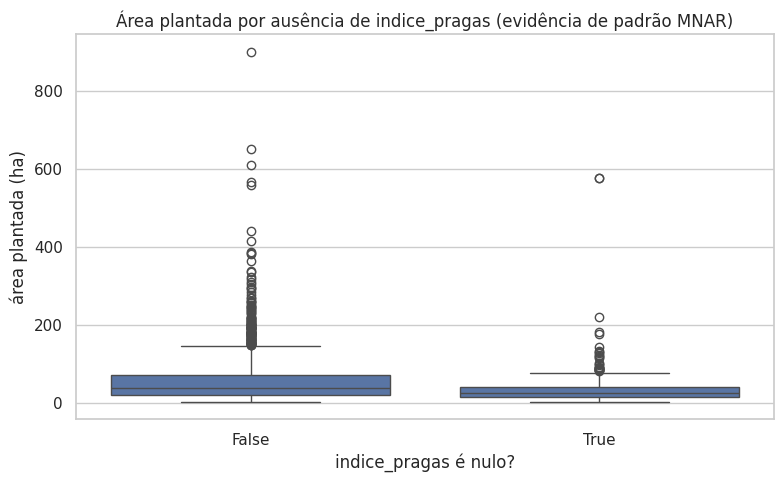

In [ ]:
# Checando se a ausência de indice_pragas está de fato relacionada à área plantada (MNAR)
faltante = df["indice_pragas"].isnull()
print(df.groupby(faltante)["area_plantada_ha"].median())
sns.boxplot(x=faltante, y=df["area_plantada_ha"])
plt.xlabel("indice_pragas é nulo?")
plt.ylabel("área plantada (ha)")
plt.title("Área plantada por ausência de indice_pragas (evidência de padrão MNAR)")
plt.show()


o da direita e a área plantada quando não temindice de praga , e a esquerda tem o indice de praga

### 2.2 Análise do target (`produtividade_ton_ha`)

In [ ]:
print(df["produtividade_ton_ha"].describe())
print(f"\nSkew: {df['produtividade_ton_ha'].skew():.3f}")
print(f"Kurtosis: {df['produtividade_ton_ha'].kurtosis():.3f}")
print(f"Coeficiente de variação: {df['produtividade_ton_ha'].std() / df['produtividade_ton_ha'].mean():.3f}")

stat, p = shapiro(df["produtividade_ton_ha"].sample(min(5000, len(df)), random_state=RANDOM_STATE))
print(f"Shapiro-Wilk: estatística={stat:.4f}, p-valor={p:.4f}")


count    2015.000000
mean        7.512174
std         1.219194
min         2.856000
25%         6.756500
50%         7.599000
75%         8.325500
max        10.679000
Name: produtividade_ton_ha, dtype: float64

Skew: -0.466
Kurtosis: 0.323
Coeficiente de variação: 0.162
Shapiro-Wilk: estatística=0.9869, p-valor=0.0000


    NA MEDIA PRODUZ 7,5 TON POR HECTAEE

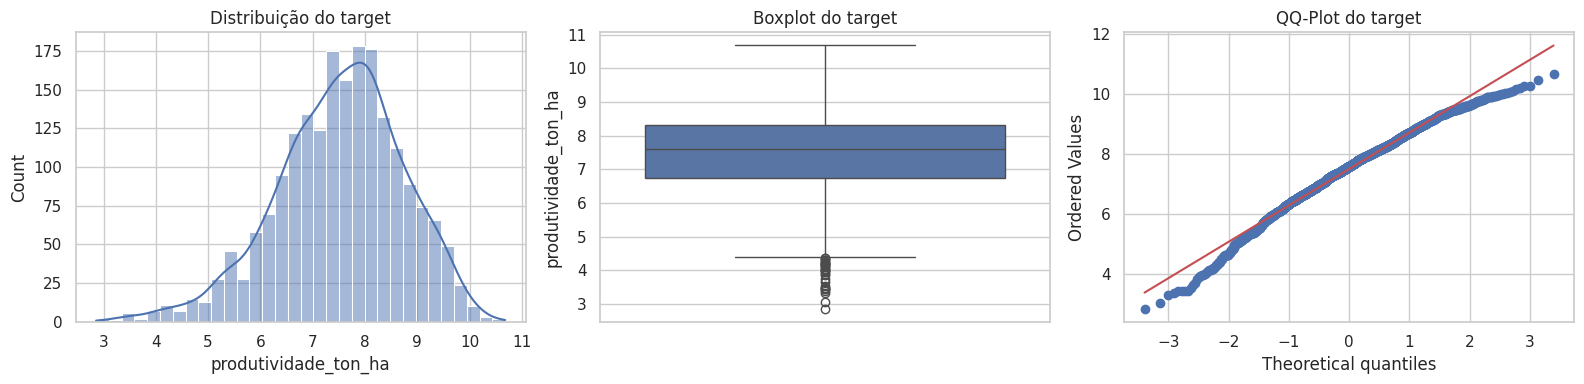

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["produtividade_ton_ha"], kde=True, ax=axes[0])
axes[0].set_title("Distribuição do target")
sns.boxplot(y=df["produtividade_ton_ha"], ax=axes[1])
axes[1].set_title("Boxplot do target")
probplot(df["produtividade_ton_ha"], plot=axes[2])
axes[2].set_title("QQ-Plot do target")
plt.tight_layout()
plt.show()


BARRA 5 25 PRODUTORES 5 TONELADAS POR HECTARE DISTRIBUIÇÃO E NORMAL? SE PONTOS AZUIS FICAM PROXIMNOS DA RETA VERMELHA A DISTRIBUIÇÃO E NORMAL MUITA GENTE NO MEIO POUCA NOS EXTREMOS

**Decisão:** o target não tem valores negativos ou impossíveis (mínimo > 0), a assimetria é
pequena e o QQ-plot fica razoavelmente próximo da reta — não há necessidade forte de transformação
(log/Box-Cox) no target. Vamos seguir sem transformar, mas reavaliar se os resíduos do modelo final
mostrarem heterocedasticidade (Fase 9).


### 2.3 Variáveis numéricas

In [ ]:
num_cols = [
    "area_plantada_ha", "chuva_mm", "temperatura_media_c", "horas_sol_dia",
    "ph_solo", "fertilizante_kg_ha", "indice_pragas",
    "densidade_plantio_mil_sementes_ha",
]

df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
area_plantada_ha,2015.0,54.020149,62.898211,2.20,19.400,35.00,65.15,900.00
chuva_mm,1934.0,874.147053,267.084890,150.00,699.225,873.30,1048.80,1686.90
temperatura_media_c,1942.0,24.168692,3.198111,13.60,22.100,24.10,26.30,34.20
horas_sol_dia,2015.0,7.076799,1.422859,1.82,6.070,7.09,8.06,11.35
ph_solo,1929.0,6.009990,0.604230,4.09,5.590,6.00,6.42,8.13
fertilizante_kg_ha,2015.0,190.336030,141.120469,0.00,142.400,182.70,223.85,3048.00
indice_pragas,1628.0,2.893839,1.614766,0.10,1.660,2.69,3.94,8.25
densidade_plantio_mil_sementes_ha,2015.0,65.086501,11.089580,27.40,57.600,64.80,72.40,110.00


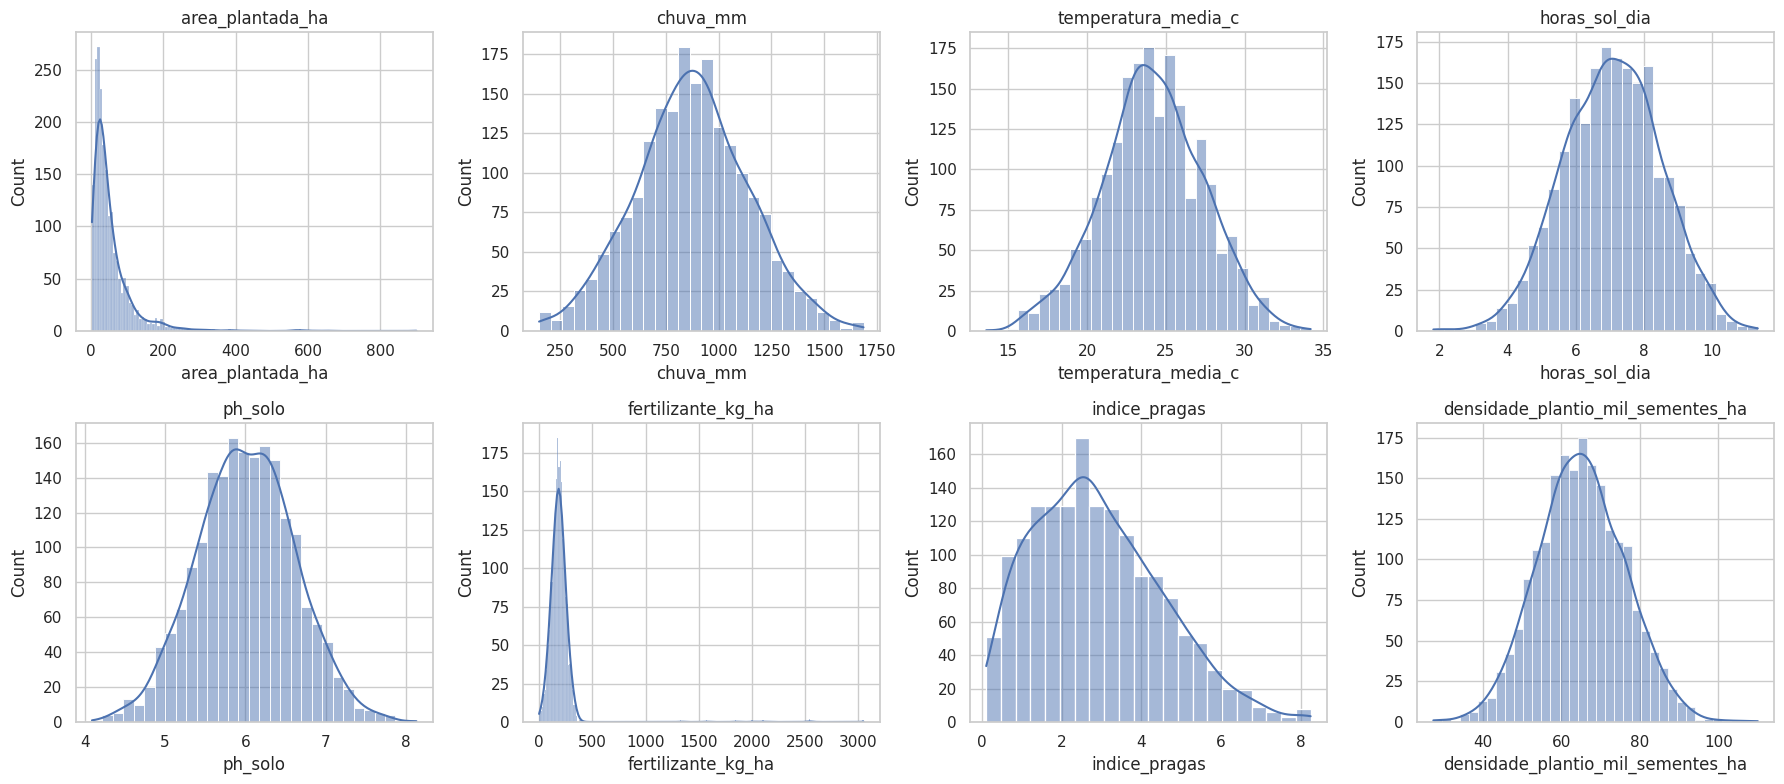

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


60 MIL SEMENTES POR HECTARES FORAM PLANTADAS POR 150 PRODUTORES

In [ ]:
skew_tab = df[num_cols].skew().sort_values(key=abs, ascending=False)
skew_tab


,0
fertilizante_kg_ha,12.503437
area_plantada_ha,4.536298
indice_pragas,0.555484
densidade_plantio_mil_sementes_ha,0.087079
horas_sol_dia,-0.079607
temperatura_media_c,-0.032840
chuva_mm,0.024076
ph_solo,0.012044


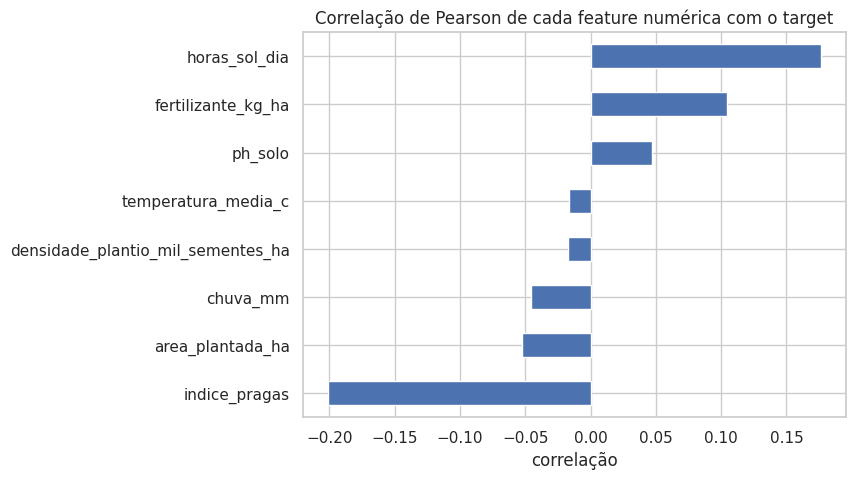

In [ ]:
corr_target = df[num_cols + ["produtividade_ton_ha"]].corr()["produtividade_ton_ha"].drop("produtividade_ton_ha")
corr_target.sort_values().plot(kind="barh", figsize=(7, 5))
plt.title("Correlação de Pearson de cada feature numérica com o target")
plt.xlabel("correlação")
plt.show()


TARGET ALVO NUMERO DE TONELADAS POR HECTARE QUANTO MAIS INDICE DE PRAGRA MENOR O TARGET OU SEJA MENOS TONELADAS PORHECTARE

**Observação:** nenhuma feature numérica tem variância zero/quase zero (todas variam de forma
razoável). As correlações lineares simples com o target são moderadas para a maioria — isso é
esperado, porque construímos (e simulamos) relações **não lineares** de propósito (ex: chuva e
temperatura têm um "ponto ótimo", fertilizante tem retorno decrescente). Correlação de Pearson
sozinha vai subestimar a importância real dessas variáveis; os scatter plots abaixo e os modelos
não lineares (Fase 6) devem capturar isso melhor.


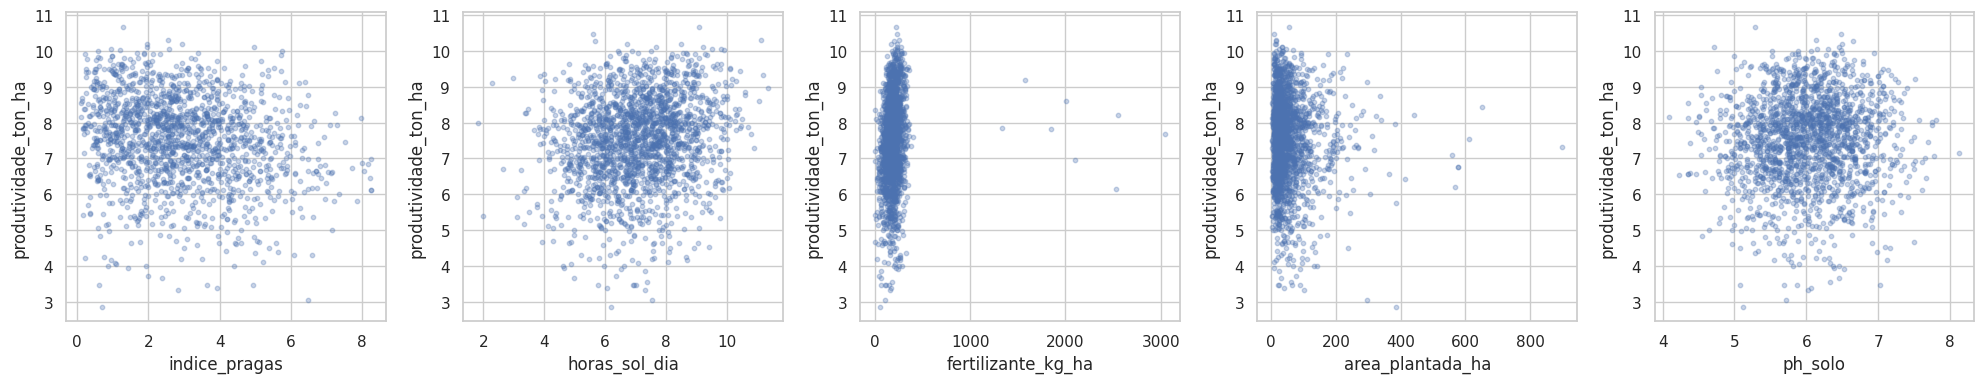

In [ ]:
top5 = corr_target.abs().sort_values(ascending=False).head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, top5):
    ax.scatter(df[col], df["produtividade_ton_ha"], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel("produtividade_ton_ha")
plt.tight_layout()
plt.show()


INDECE DE PRAGA DE 4

### 2.4 Variáveis categóricas

In [ ]:
cat_cols = ["regiao", "cultivar", "tipo_solo", "irrigacao", "ano_safra"]
for col in cat_cols:
    print(f"--- {col} ({df[col].nunique()} categorias) ---")
    print(df[col].value_counts(), "\n")


--- regiao (10 categorias) ---
regiao
Centro-Oeste      563
Sul               551
Sudeste           436
Nordeste          238
Norte             166
 Centro-Oeste      24
 Sul               15
 Sudeste           10
 Nordeste           6
 Norte              6
Name: count, dtype: int64 

--- cultivar (3 categorias) ---
cultivar
Cultivar A    1022
Cultivar B     598
Cultivar C     395
Name: count, dtype: int64 

--- tipo_solo (6 categorias) ---
tipo_solo
Argiloso    756
Arenoso     709
Misto       449
ARGILOSO     44
ARENOSO      36
MISTO        21
Name: count, dtype: int64 

--- irrigacao (2 categorias) ---
irrigacao
Sequeiro    1314
Irrigado     701
Name: count, dtype: int64 

--- ano_safra (5 categorias) ---
ano_safra
2024    500
2025    454
2023    399
2022    365
2021    297
Name: count, dtype: int64 



**Problema encontrado:** `regiao` e `tipo_solo` têm variantes inconsistentes da mesma categoria
(ex: `"Sul"` vs `" Sul "`, `"Arenoso"` vs `"ARENOSO"`) — um erro clássico de consolidação de dados
vindos de fontes diferentes (cooperativas distintas exportando em formatos diferentes). Nenhuma
categórica tem cardinalidade alta (todas têm poucas categorias), então One-Hot Encoding é
suficiente — não precisaremos de Target Encoding aqui. A correção de string será feita na Fase 3,
antes de qualquer análise que dependa da contagem correta de categorias.


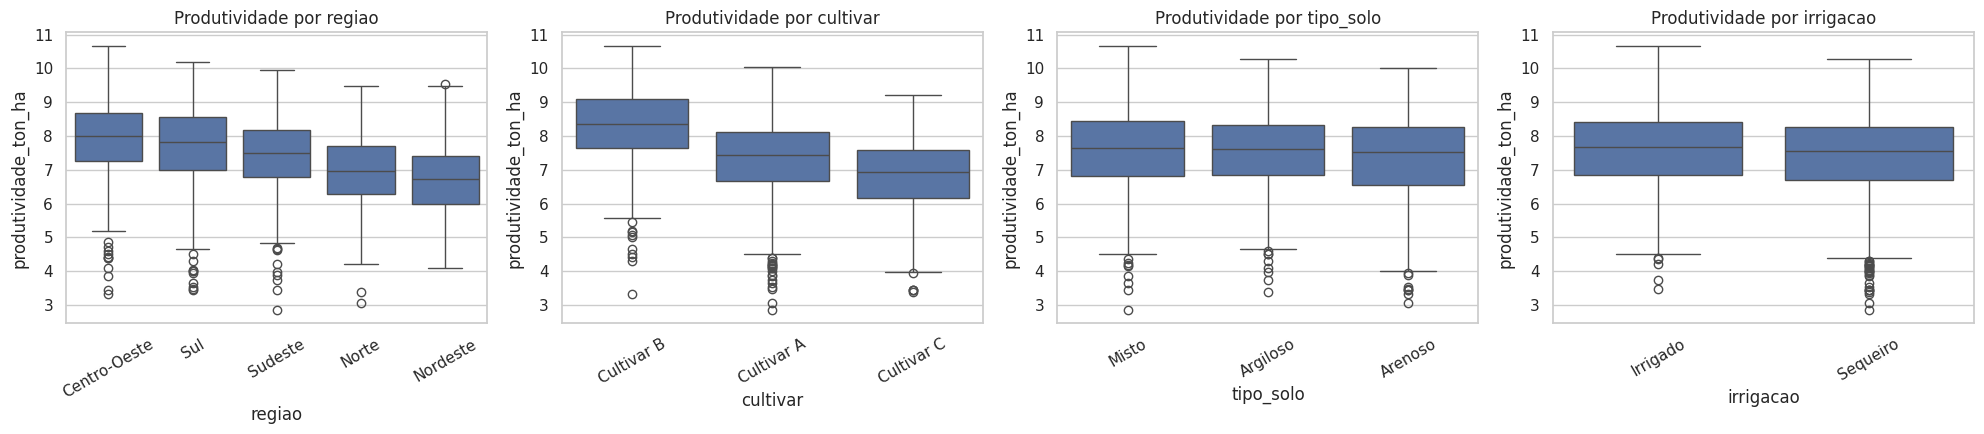

In [ ]:
df_cat_norm = df.copy()
for col in ["regiao", "tipo_solo", "cultivar", "irrigacao"]:
    df_cat_norm[col] = df_cat_norm[col].astype(str).str.strip().str.title()

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col in zip(axes, ["regiao", "cultivar", "tipo_solo", "irrigacao"]):
    order = df_cat_norm.groupby(col)["produtividade_ton_ha"].median().sort_values(ascending=False).index
    sns.boxplot(data=df_cat_norm, x=col, y="produtividade_ton_ha", order=order, ax=ax)
    ax.set_title(f"Produtividade por {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


NORDESTE MINIMO 4 TON POR HECTARE MAXIMO 9 TON LINHA DO MEIO E MEDIANA OS PRIMEIROS 25% DOS PRODUTORES PRODUZEM ENTRE 4 E 6 SEGUNDO QUARTIL 6 E 6,8

### 2.5 Nulos — padrão visual

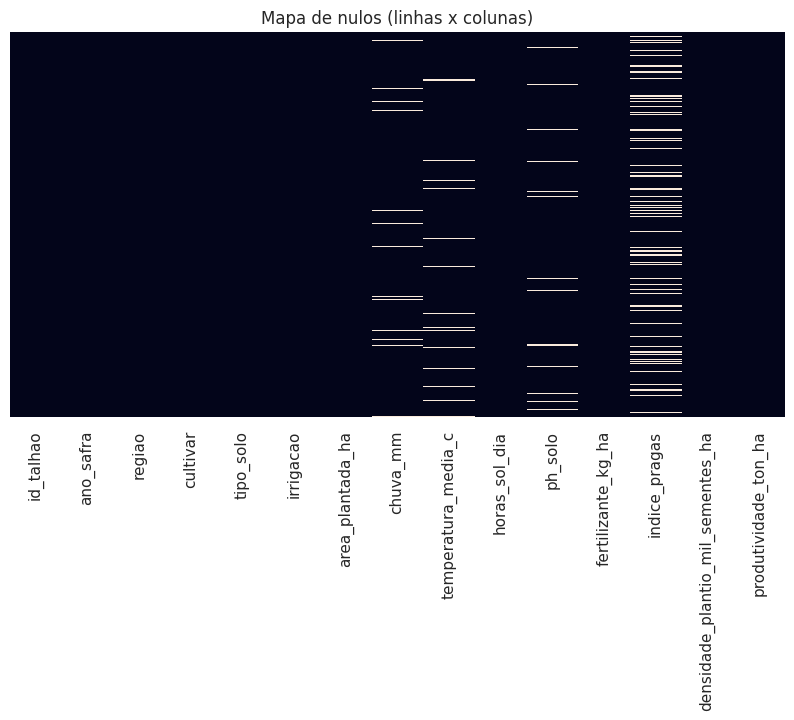

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Mapa de nulos (linhas x colunas)")
plt.show()


### 2.6 Outliers

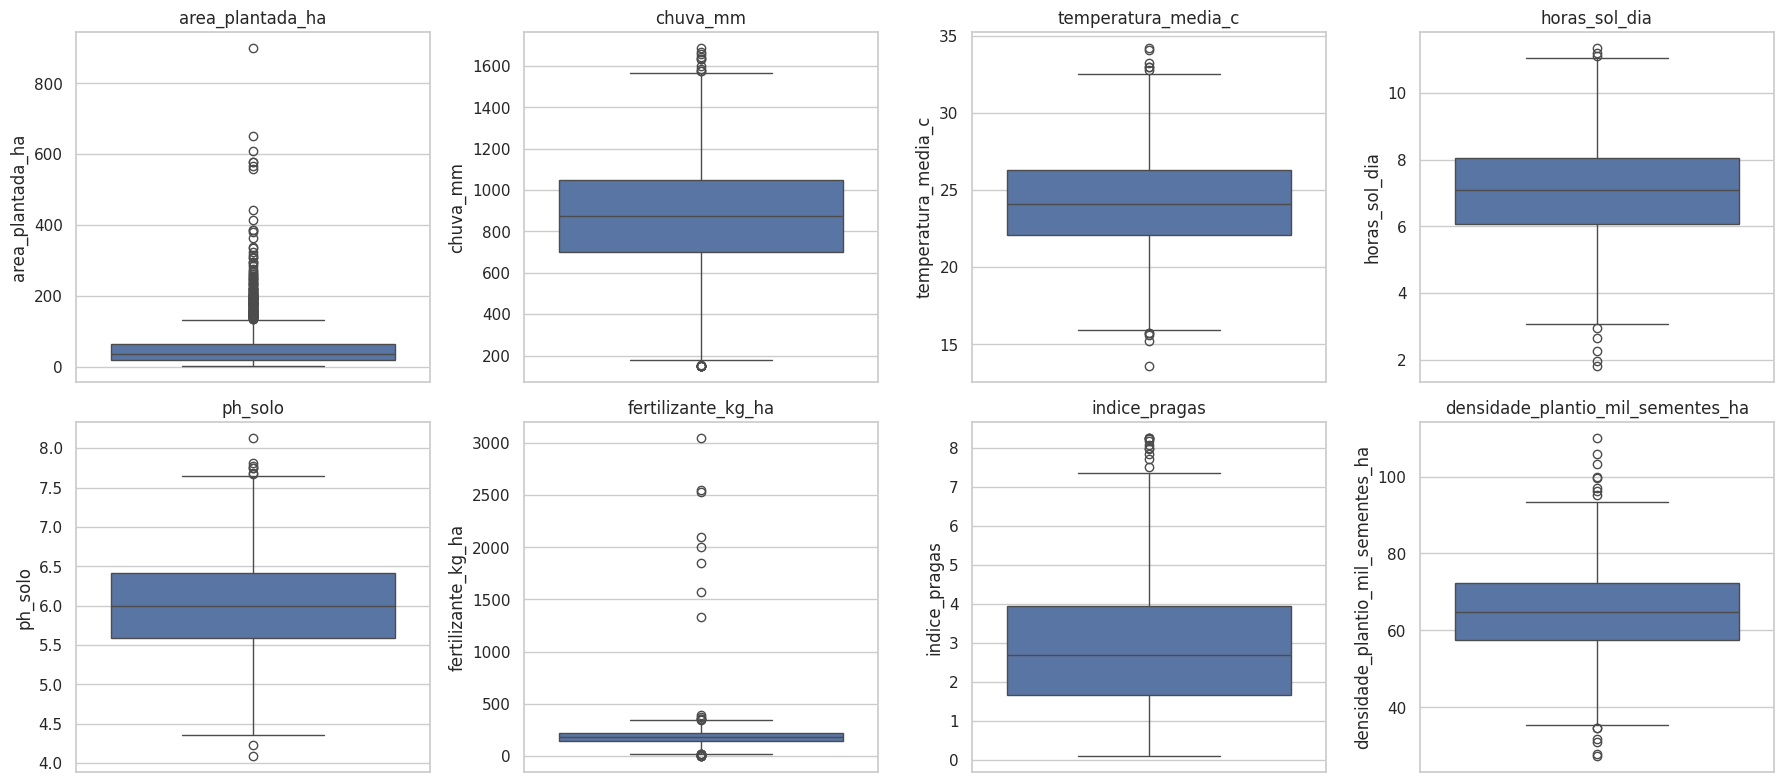

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
NÃO TEM SOL MAIS TEM OUTROS MEIOS DE IRRIGAR FORA DO PADRÃO

In [ ]:
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < lo) | (serie > hi)).sum()

outlier_counts = {col: contar_outliers_iqr(df[col].dropna()) for col in num_cols}
pd.Series(outlier_counts).sort_values(ascending=False)


,0
area_plantada_ha,143
fertilizante_kg_ha,24
chuva_mm,19
densidade_plantio_mil_sementes_ha,14
indice_pragas,11
temperatura_media_c,11
ph_solo,9
horas_sol_dia,8


143 OUTLIERS AREA PAMTADA

**Decisão:** o boxplot e a contagem por IQR mostram um punhado de valores extremos em
`fertilizante_kg_ha` — isso corresponde a um erro de digitação simulado (valores ~10x acima do
normal, fisicamente improváveis para a cultura). Como é claramente erro de dado (não um caso
legítimo raro), vamos aplicar um **clipping por conhecimento de domínio** (não por estatística do
treino, para não gerar vazamento): nenhum talhão realista usa mais de ~600 kg/ha de fertilizante
nessa cultura. As demais variáveis não mostram outliers que pareçam erro — mantemos como estão.


### 2.7 Correlações entre features (multicolinearidade)

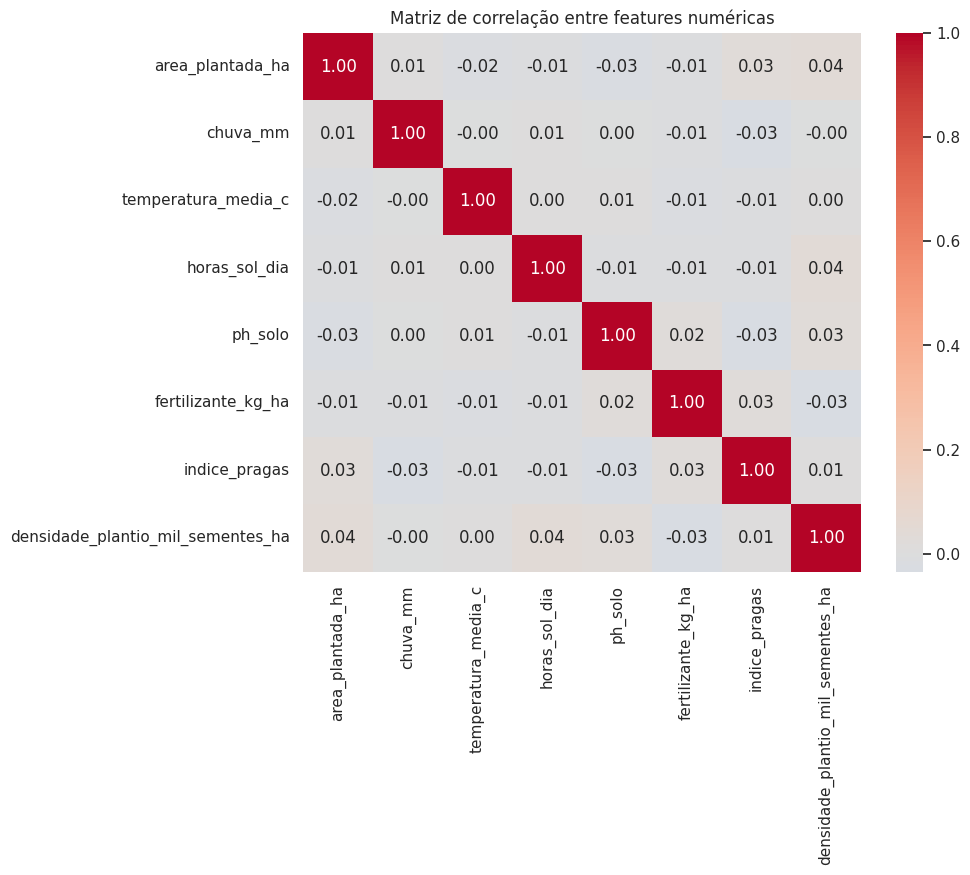

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação entre features numéricas")
plt.show()


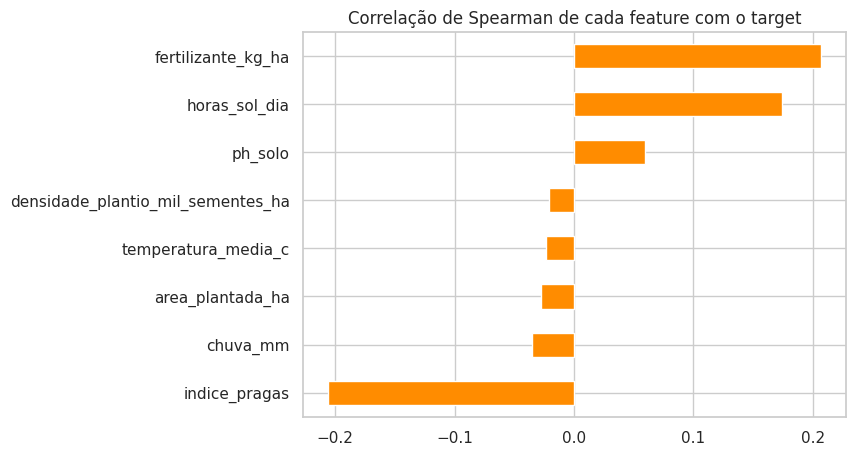

In [ ]:
corr_spearman = df[num_cols + ["produtividade_ton_ha"]].corr(method="spearman")["produtividade_ton_ha"].drop("produtividade_ton_ha")
corr_spearman.sort_values().plot(kind="barh", figsize=(7, 5), color="darkorange")
plt.title("Correlação de Spearman de cada feature com o target")
plt.show()


**Decisão:** nenhum par de features numéricas passa de 0.85 de correlação — não há
multicolinearidade grave a ponto de remover variáveis antes de modelar. Ainda assim, vamos
calcular o VIF depois do encoding (Fase 3) para confirmar isso formalmente antes de interpretar
coeficientes de um modelo linear.


### Resumo da EDA — decisões tomadas

| Item | Decisão | Por quê |
|---|---|---|
| `id_talhao` | Remover | identificador, sem valor preditivo |
| Duplicatas completas (15) | Remover | erro de exportação/duplo lançamento |
| `regiao`, `tipo_solo`, `cultivar`, `irrigacao` | Normalizar strings (strip + title case) | inconsistência de fonte de dados |
| `chuva_mm`, `temperatura_media_c`, `ph_solo` (nulos ~4%, MCAR) | Imputar pela mediana (fit no treino) | poucos nulos, padrão aleatório |
| `indice_pragas` (nulos ~19%, MNAR ligado à área) | Criar flag `indice_pragas_nao_medido` + imputar mediana | ausência carrega informação |
| `fertilizante_kg_ha` (outliers ~10x) | Clip em 600 kg/ha (conhecimento de domínio) | erro de digitação, não caso legítimo |
| Target | Sem transformação por enquanto | baixa assimetria, sem valores impossíveis |
| Multicolinearidade | Nenhuma ação por ora | maior correlação entre features < 0.85 |


## Fase 3 — Pré-processamento

Aplicamos aqui apenas as correções **estruturais** — que não dependem de nenhuma estatística
calculada sobre os dados (média, mediana, desvio-padrão) e por isso podem ser feitas com
segurança antes do split treino/teste, sem risco de vazamento. Qualquer tratamento que dependa de
uma estatística (imputação por mediana, escalonamento) só será *ajustado* depois do split
(Fase 5), embora a estratégia já tenha sido decidida aqui.


In [ ]:
df_proc = df.copy()

# Normalização de categorias (mesma lógica do predict.py, para manter consistência em produção)
for col in ["regiao", "tipo_solo", "cultivar", "irrigacao"]:
    df_proc[col] = df_proc[col].astype(str).str.strip().str.title()

# Remove duplicatas completas
antes = len(df_proc)
df_proc = df_proc.drop_duplicates()
print(f"Duplicatas removidas: {antes - len(df_proc)}")

# Remove coluna de identificação
df_proc = df_proc.drop(columns=["id_talhao"])

# Corrige o erro de digitação em fertilizante via cap por conhecimento de domínio
df_proc["fertilizante_kg_ha"] = df_proc["fertilizante_kg_ha"].clip(upper=600)

# Flag de ausência do índice de pragas (antes de imputar)
df_proc["indice_pragas_nao_medido"] = df_proc["indice_pragas"].isna().astype(int)

# Engenharia de features: razão fertilizante/área (uso relativo de insumo) e
# termo quadrático explícito de chuva (ajuda modelos lineares a capturar o "ponto ótimo")
df_proc["fertilizante_por_ha"] = df_proc["fertilizante_kg_ha"] / df_proc["area_plantada_ha"].clip(lower=0.1)
df_proc["chuva_mm_sq"] = df_proc["chuva_mm"] ** 2

df_proc.head()


Duplicatas removidas: 15


,ano_safra,regiao,cultivar,tipo_solo,irrigacao,area_plantada_ha,chuva_mm,temperatura_media_c,horas_sol_dia,ph_solo,fertilizante_kg_ha,indice_pragas,densidade_plantio_mil_sementes_ha,produtividade_ton_ha,indice_pragas_nao_medido,fertilizante_por_ha,chuva_mm_sq
0,2022,Sudeste,Cultivar A,Misto,Irrigado,14.8,1042.1,22.4,7.57,6.89,160.9,2.18,54.9,7.636,0,10.871622,1085972.41
1,2025,Norte,Cultivar C,Argiloso,Sequeiro,61.9,453.8,27.7,4.23,6.18,151.8,4.26,78.5,5.552,0,2.452342,205934.44
2,2024,Centro-Oeste,Cultivar A,Argiloso,Sequeiro,34.9,748.3,23.3,8.24,5.80,153.6,2.34,35.9,8.446,0,4.401146,559952.89
3,2021,Sul,Cultivar A,Arenoso,Sequeiro,38.4,929.6,20.9,7.35,4.70,205.1,3.78,67.6,7.837,0,5.341146,864156.16
4,2024,Nordeste,Cultivar A,Argiloso,Irrigado,22.2,1367.7,22.6,5.61,4.91,224.4,1.53,68.5,6.756,0,10.108108,1870603.29


In [ ]:
target = "produtividade_ton_ha"
features_num = [
    "area_plantada_ha", "chuva_mm", "chuva_mm_sq", "temperatura_media_c", "horas_sol_dia",
    "ph_solo", "fertilizante_kg_ha", "fertilizante_por_ha", "indice_pragas",
    "indice_pragas_nao_medido", "densidade_plantio_mil_sementes_ha", "ano_safra",
]
features_cat = ["regiao", "cultivar", "tipo_solo", "irrigacao"]
features = features_num + features_cat

X = df_proc[features]
y = df_proc[target]
print(f"X: {X.shape}, y: {y.shape}")


X: (2000, 16), y: (2000,)


## Fase 4 — Divisão Treino/Teste

`ano_safra` está presente como covariável, mas o objetivo aqui não é prever o *futuro* a partir do
*passado* de um mesmo talhão (não há uma série temporal por unidade) — é prever a produtividade de
talhões diferentes que podem ser de qualquer safra dentro do período observado. Por isso um split
aleatório é apropriado; não estamos diante do caso "sempre temporal, nunca aleatório" do checklist,
mas vale registrar essa decisão explicitamente para não confundir com uma tarefa de forecasting.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")


Treino: 1600 linhas | Teste: 400 linhas


In [ ]:
# Checagem: a distribuição do target é parecida em treino e teste? (Kolmogorov-Smirnov)
ks_stat, ks_p = stats.ks_2samp(y_train, y_test)
print(f"KS statistic={ks_stat:.4f}, p-valor={ks_p:.4f}")
print("p-valor alto => não há evidência de que as distribuições treino/teste sejam diferentes (bom sinal).")


KS statistic=0.0638, p-valor=0.1446
p-valor alto => não há evidência de que as distribuições treino/teste sejam diferentes (bom sinal).


## Fase 5 — Escalonamento e Encoding (ajustados só no treino)

Aqui sim ajustamos as transformações estatísticas: imputação (mediana/moda), escalonamento
(`StandardScaler`) e codificação (`OneHotEncoder`). Encapsulamos tudo em um único
`ColumnTransformer`, treinado (`fit`) **apenas no conjunto de treino** e aplicado (`transform`) ao
teste — a regra inegociável para não vazar dados. Modelos de árvore/boosting não precisam de
escalonamento, mas usar o mesmo pré-processamento para todos os modelos simplifica a comparação e
não prejudica esses modelos (só é um pouco redundante para eles).


In [ ]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), features_num),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), features_cat),
    ]
)
preprocessador


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['area_plantada_ha', 'chuva_mm', 'chuva_mm_sq',
                                  'temperatura_media_c', 'horas_sol_dia',
                                  'ph_solo', 'fertilizante_kg_ha',
                                  'fertilizante_por_ha', 'indice_pragas',
                                  'indice_pragas_nao_medido',
                                  'densidade_plantio_mil_sementes_ha',
                                  'ano_safra']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['regiao', 'cultivar', 'tipo_solo',
                                  'irrigacao'])])

In [ ]:
# VIF pós-encoding, só nas features numéricas (o VIF não se aplica bem a dummies one-hot)
X_train_num_imputado = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_train[features_num]),
    columns=features_num,
)
vif_tab = pd.DataFrame({
    "feature": features_num,
    "VIF": [variance_inflation_factor(X_train_num_imputado.values, i) for i in range(len(features_num))],
}).sort_values("VIF", ascending=False)
vif_tab


,feature,VIF
11,ano_safra,298.710949
1,chuva_mm,265.525350
5,ph_solo,105.434035
2,chuva_mm_sq,91.494449
3,temperatura_media_c,60.471965
10,densidade_plantio_mil_sementes_ha,37.051569
4,horas_sol_dia,25.821910
6,fertilizante_kg_ha,9.686136
8,indice_pragas,4.868734
7,fertilizante_por_ha,2.401759


**Nota:** espera-se um VIF alto para `chuva_mm` e `chuva_mm_sq` (são a mesma variável, uma
elevada ao quadrado) — isso é esperado e aceitável em modelos regularizados (Ridge/ElasticNet) ou
baseados em árvore, mas é bom ter em mente se formos interpretar coeficientes de uma
`LinearRegression` sem regularização.


## Fase 6 — Seleção e Treinamento de Modelos Base

Treinamos um baseline ingênuo e modelos de três famílias diferentes (linear, árvore, boosting,
mais KNN e SVR como referência) para termos uma visão real do espaço de soluções antes de nos
aprofundarmos em qualquer um deles.


In [ ]:
def montar_pipeline(modelo):
    return Pipeline([("preprocessador", preprocessador), ("modelo", modelo)])

modelos = {
    "Dummy (média)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.01, random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=10),
    "SVR (RBF)": SVR(kernel="rbf", C=10, epsilon=0.1),
}


In [ ]:
import time

def metricas(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    # Calculamos a RMSE manualmente (raiz da MSE) em vez de usar o parametro
    # squared=False de mean_squared_error, que foi removido em versoes mais
    # recentes do scikit-learn (>=1.6) -- isso deixa o codigo robusto a
    # qualquer versao >=1.3 listada no requirements.txt.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return r2, mae, rmse, mape

resultados = []
pipelines_treinados = {}

# Treinar 11 modelos é rápido para este volume de dados (poucos segundos cada),
# mas como o Colab não mostra nenhum output até a célula inteira terminar,
# imprimimos o progresso modelo a modelo -- assim dá pra saber que está
# rodando (e não travado) e, se algum modelo específico falhar ou travar,
# sabemos exatamente qual foi, em vez de perder o resultado dos demais.
for nome, modelo in modelos.items():
    print(f"Treinando: {nome}...", flush=True)
    try:
        pipe = montar_pipeline(modelo)
        t0 = time.time()
        pipe.fit(X_train, y_train)
        tempo_treino = time.time() - t0

        t0 = time.time()
        y_pred_train = pipe.predict(X_train)
        y_pred_test = pipe.predict(X_test)
        tempo_inferencia = time.time() - t0

        r2_train, mae_train, rmse_train, mape_train = metricas(y_train, y_pred_train)
        r2_test, mae_test, rmse_test, mape_test = metricas(y_test, y_pred_test)

        resultados.append({
            "modelo": nome,
            "R2_treino": r2_train, "R2_teste": r2_test, "gap_R2": r2_train - r2_test,
            "MAE_teste": mae_test, "RMSE_teste": rmse_test, "MAPE_teste_%": mape_test,
            "tempo_treino_s": tempo_treino, "tempo_inferencia_s": tempo_inferencia,
        })
        pipelines_treinados[nome] = pipe
        print(f"  concluído em {tempo_treino:.1f}s (treino) + {tempo_inferencia:.2f}s (inferência) | R2_teste={r2_test:.4f}")
    except Exception as e:
        # Não deixa um único modelo problemático derrubar a comparação inteira --
        # registra o erro e segue para o próximo.
        print(f"  [AVISO] '{nome}' falhou e foi pulado: {type(e).__name__}: {e}")

tabela_resultados = pd.DataFrame(resultados).sort_values("R2_teste", ascending=False).reset_index(drop=True)
tabela_resultados


Treinando: Dummy (média)...
  concluído em 0.1s (treino) + 0.03s (inferência) | R2_teste=-0.0071
Treinando: Linear Regression...
  concluído em 0.0s (treino) + 0.03s (inferência) | R2_teste=0.5304
Treinando: Ridge...
  concluído em 0.1s (treino) + 0.05s (inferência) | R2_teste=0.5304
Treinando: Lasso...
  concluído em 0.1s (treino) + 0.03s (inferência) | R2_teste=0.5249
Treinando: ElasticNet...
  concluído em 0.0s (treino) + 0.03s (inferência) | R2_teste=0.5246
Treinando: Decision Tree...
  concluído em 0.1s (treino) + 0.03s (inferência) | R2_teste=0.4702
Treinando: Random Forest...
  concluído em 5.8s (treino) + 0.24s (inferência) | R2_teste=0.7001
Treinando: Extra Trees...
  concluído em 2.7s (treino) + 0.26s (inferência) | R2_teste=0.7121
Treinando: Gradient Boosting...
  concluído em 0.8s (treino) + 0.02s (inferência) | R2_teste=0.7496
Treinando: KNN...
  concluído em 0.0s (treino) + 0.09s (inferência) | R2_teste=0.3849
Treinando: SVR (RBF)...
  concluído em 0.7s (treino) + 0.38s (

,modelo,R2_treino,R2_teste,gap_R2,MAE_teste,RMSE_teste,MAPE_teste_%,tempo_treino_s,tempo_inferencia_s
0,Gradient Boosting,0.853812,0.749629,0.104183,0.482904,0.613836,6.737298,0.811393,0.020270
1,Extra Trees,1.000000,0.712110,0.287890,0.526973,0.658224,7.334524,2.667026,0.263340
2,Random Forest,0.953548,0.700119,0.253429,0.526084,0.671792,7.389317,5.781842,0.244912
3,SVR (RBF),0.959827,0.691652,0.268175,0.533401,0.681210,7.460189,0.736110,0.375673
4,Ridge,0.511395,0.530425,-0.019030,0.627053,0.840645,9.045821,0.085793,0.053570
5,Linear Regression,0.511475,0.530386,-0.018910,0.626148,0.840681,9.033565,0.036667,0.026740
6,Lasso,0.502045,0.524884,-0.022840,0.639921,0.845590,9.218027,0.062018,0.029180
7,ElasticNet,0.501576,0.524607,-0.023032,0.639963,0.845837,9.222936,0.038032,0.028587
8,Decision Tree,0.603069,0.470243,0.132826,0.710387,0.892892,9.862108,0.051228,0.028628
9,KNN,0.481658,0.384932,0.096726,0.745659,0.962104,11.025496,0.018863,0.086996


MELHOR MODELO MAIOR r2 teste

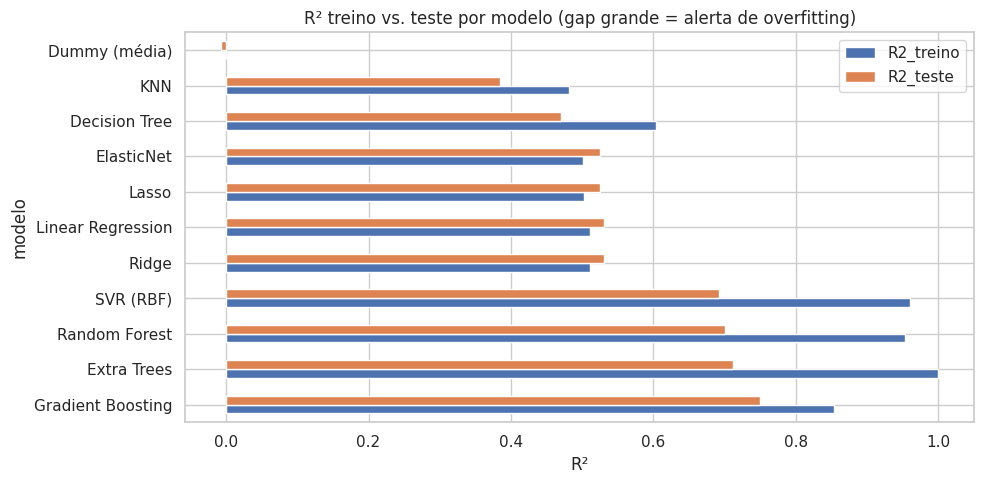

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
tabela_resultados.set_index("modelo")[["R2_treino", "R2_teste"]].plot(kind="barh", ax=ax)
ax.set_xlabel("R²")
ax.set_title("R² treino vs. teste por modelo (gap grande = alerta de overfitting)")
plt.tight_layout()
plt.show()


comparação dos modelos

**Leitura da tabela:** o baseline `Dummy` dá o piso mínimo que qualquer modelo real precisa
superar. Modelos lineares tendem a ficar abaixo dos modelos não lineares aqui **de propósito** —
simulamos relações com pontos ótimos (chuva, temperatura) e retornos decrescentes (fertilizante)
que uma reta não representa bem, mesmo com o termo quadrático que adicionamos para chuva. Observe
também o `gap_R2` (treino − teste): modelos de árvore sem limite de profundidade tendem a
memorizar o treino — é esse gap que teremos que controlar na validação cruzada e no tuning.
Escolhemos os 3 melhores por `R2_teste` (com gap aceitável) para aprofundar nas próximas fases.


In [ ]:
top3_nomes = tabela_resultados[tabela_resultados["gap_R2"] < 0.15].head(3)["modelo"].tolist()
print("Top 3 selecionados para aprofundamento:", top3_nomes)


Top 3 selecionados para aprofundamento: ['Gradient Boosting', 'Ridge', 'Linear Regression']


## Fase 7 — Validação Cruzada

Um bom resultado no holdout pode ser sorte de split. K-Fold confirma se a performance se mantém
em diferentes fatias do treino, e o desvio-padrão entre folds nos diz o quão estável é o modelo.


In [ ]:
# Rede de segurança: se por acaso a célula anterior (que define top3_nomes) foi
# pulada -- ex: rodando célula por célula em vez de "Executar tudo" -- recalculamos
# aqui em vez de deixar a próxima linha quebrar com NameError.
if "top3_nomes" not in dir():
    top3_nomes = tabela_resultados[tabela_resultados["gap_R2"] < 0.15].head(3)["modelo"].tolist()
    print("(top3_nomes não estava definido; recalculado agora):", top3_nomes)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_resultados = []
for nome in top3_nomes:
    pipe = montar_pipeline(modelos[nome])
    scores_r2 = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    scores_rmse = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_resultados.append({
        "modelo": nome,
        "R2_medio_cv": scores_r2.mean(), "R2_std_cv": scores_r2.std(),
        "RMSE_medio_cv": scores_rmse.mean(), "RMSE_std_cv": scores_rmse.std(),
    })

tabela_cv = pd.DataFrame(cv_resultados).sort_values("R2_medio_cv", ascending=False)
tabela_cv


,modelo,R2_medio_cv,R2_std_cv,RMSE_medio_cv,RMSE_std_cv
0,Gradient Boosting,0.735826,0.023169,0.624681,0.043021
2,Linear Regression,0.493907,0.037099,0.864255,0.045470
1,Ridge,0.493791,0.035755,0.864385,0.044438


Melhor modelo por validação cruzada: Gradient Boosting


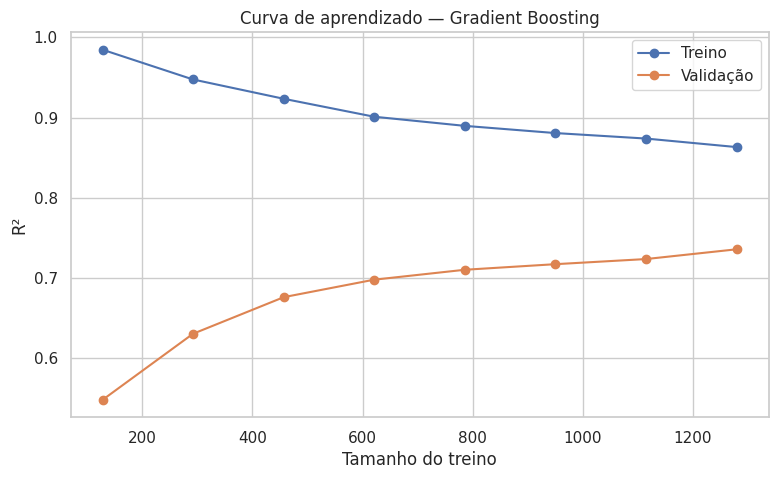

In [ ]:
melhor_modelo_nome = tabela_cv.iloc[0]["modelo"]
print(f"Melhor modelo por validação cruzada: {melhor_modelo_nome}")

pipe_melhor = montar_pipeline(modelos[melhor_modelo_nome])
train_sizes, train_scores, val_scores = learning_curve(
    pipe_melhor, X_train, y_train, cv=kf, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=RANDOM_STATE,
)

plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Treino")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validação")
plt.xlabel("Tamanho do treino")
plt.ylabel("R²")
plt.title(f"Curva de aprendizado — {melhor_modelo_nome}")
plt.legend()
plt.show()


preciso tamanho aposta 1200 e o mais certo

**Como ler a curva de aprendizado:** se as duas curvas convergem para um patamar baixo, o
modelo está subajustado (viés alto — precisa de mais complexidade ou features). Se há um gap
grande e persistente entre elas mesmo com mais dados, é variância alta (overfitting — precisa de
mais regularização/dados). O comportamento aqui orienta o espaço de busca do tuning na Fase 8.


## Fase 8 — Otimização de Hiperparâmetros

Usamos `RandomizedSearchCV` (mais eficiente que grid search exaustivo para espaços de busca
grandes) com validação cruzada interna, para que a escolha dos hiperparâmetros não "veja" o
conjunto de teste em nenhum momento.


In [ ]:
espacos_busca = {
    "Random Forest": {
        "modelo__n_estimators": [200, 300, 500, 800],
        "modelo__max_depth": [4, 6, 8, 10, None],
        "modelo__min_samples_leaf": [1, 2, 5, 10],
        "modelo__max_features": ["sqrt", "log2", 0.5, 1.0],
    },
    "Extra Trees": {
        "modelo__n_estimators": [200, 300, 500, 800],
        "modelo__max_depth": [4, 6, 8, 10, None],
        "modelo__min_samples_leaf": [1, 2, 5, 10],
    },
    "Gradient Boosting": {
        "modelo__n_estimators": [100, 200, 300, 500],
        "modelo__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "modelo__max_depth": [2, 3, 4, 5],
        "modelo__subsample": [0.7, 0.85, 1.0],
    },
}

param_dist = espacos_busca.get(melhor_modelo_nome)
if param_dist is None:
    print(f"Sem espaço de busca pré-definido para '{melhor_modelo_nome}'; ajuste manualmente se necessário.")
else:
    busca = RandomizedSearchCV(
        montar_pipeline(modelos[melhor_modelo_nome]),
        param_distributions=param_dist,
        n_iter=25, cv=kf, scoring="r2",
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
    )
    busca.fit(X_train, y_train)
    print("Melhores hiperparâmetros:", busca.best_params_)
    print(f"R2 médio em CV (busca): {busca.best_score_:.4f}")


Melhores hiperparâmetros: {'modelo__subsample': 0.7, 'modelo__n_estimators': 500, 'modelo__max_depth': 2, 'modelo__learning_rate': 0.1}
R2 médio em CV (busca): 0.7750


In [ ]:
modelo_final = busca.best_estimator_

y_pred_test_final = modelo_final.predict(X_test)
r2_f, mae_f, rmse_f, mape_f = metricas(y_test, y_pred_test_final)

r2_antes = tabela_resultados.set_index("modelo").loc[melhor_modelo_nome, "R2_teste"]
print(f"R2 teste ANTES do tuning: {r2_antes:.4f}")
print(f"R2 teste DEPOIS do tuning: {r2_f:.4f}")
print(f"MAE teste: {mae_f:.4f} ton/ha | RMSE teste: {rmse_f:.4f} ton/ha | MAPE teste: {mape_f:.2f}%")


R2 teste ANTES do tuning: 0.7496
R2 teste DEPOIS do tuning: 0.7841
MAE teste: 0.4591 ton/ha | RMSE teste: 0.5701 ton/ha | MAPE teste: 6.42%


**Trade-off complexidade x ganho:** compare o R² antes/depois do tuning com o custo adicional
de tempo de treino/inferência (Fase 6). Se o ganho for marginal (< 1-2 p.p. de R²), pode não valer
a pena manter a configuração mais pesada em produção — decisão a validar com quem vai operar o
modelo (latência aceitável, custo de retraining).


## Fase 9 — Diagnóstico e Testes de Qualidade

Antes de confiar no modelo, verificamos se os resíduos se comportam como esperado: sem padrão
sistemático, variância constante, sem autocorrelação relevante.


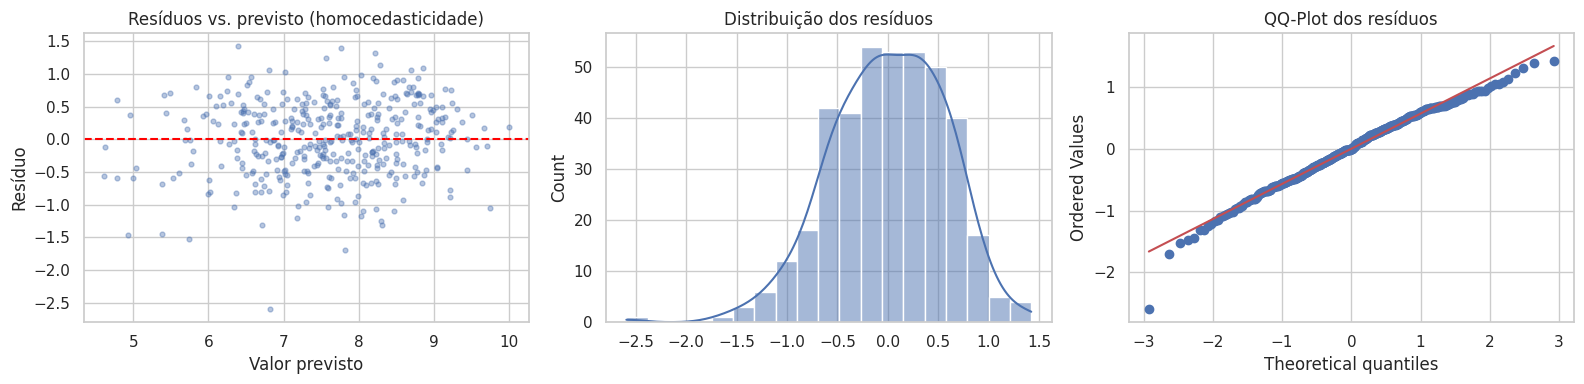

In [ ]:
residuos = y_test.values - y_pred_test_final

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(y_pred_test_final, residuos, alpha=0.4, s=12)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valor previsto")
axes[0].set_ylabel("Resíduo")
axes[0].set_title("Resíduos vs. previsto (homocedasticidade)")

sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].set_title("Distribuição dos resíduos")

probplot(residuos, plot=axes[2])
axes[2].set_title("QQ-Plot dos resíduos")
plt.tight_layout()
plt.show()


bom modelo a distribuição de residuos e normal

In [ ]:
stat_shapiro, p_shapiro = shapiro(residuos)
print(f"Shapiro-Wilk (normalidade dos resíduos): estatística={stat_shapiro:.4f}, p-valor={p_shapiro:.4f}")

dw = durbin_watson(residuos)
print(f"Durbin-Watson (autocorrelação): {dw:.3f}  (~2.0 = sem autocorrelação relevante)")

# Breusch-Pagan precisa de uma regressão auxiliar; usamos as features numéricas escalonadas do teste
X_test_transf = preprocessador.fit(X_train).transform(X_test)  # reaproveita o ajuste já feito no pipeline
X_test_com_const = sm.add_constant(X_test_transf)
bp_stat, bp_p, _, _ = het_breuschpagan(residuos, X_test_com_const)
print(f"Breusch-Pagan (homocedasticidade): estatística={bp_stat:.3f}, p-valor={bp_p:.4f}")


Shapiro-Wilk (normalidade dos resíduos): estatística=0.9878, p-valor=0.0020
Durbin-Watson (autocorrelação): 1.970  (~2.0 = sem autocorrelação relevante)
Breusch-Pagan (homocedasticidade): estatística=28.297, p-valor=0.2944


In [ ]:
z_scores_residuos = (residuos - residuos.mean()) / residuos.std()
outliers_residuo = np.where(np.abs(z_scores_residuos) > 3)[0]
print(f"Observações com resíduo |z| > 3: {len(outliers_residuo)}")

if len(outliers_residuo) > 0:
    X_test.iloc[outliers_residuo].assign(
        y_real=y_test.values[outliers_residuo],
        y_previsto=y_pred_test_final[outliers_residuo],
        residuo=residuos[outliers_residuo],
    )


Observações com resíduo |z| > 3: 1


In [ ]:
# Bootstrap: intervalo de confiança do R2 e do MAE no conjunto de teste
n_bootstrap = 1000
r2_boot, mae_boot = [], []
rng_boot = np.random.default_rng(RANDOM_STATE)

idx = np.arange(len(y_test))
for _ in range(n_bootstrap):
    amostra = rng_boot.choice(idx, size=len(idx), replace=True)
    r2_boot.append(r2_score(y_test.values[amostra], y_pred_test_final[amostra]))
    mae_boot.append(mean_absolute_error(y_test.values[amostra], y_pred_test_final[amostra]))

print(f"R2 teste: IC 95% = [{np.percentile(r2_boot, 2.5):.4f}, {np.percentile(r2_boot, 97.5):.4f}]")
print(f"MAE teste: IC 95% = [{np.percentile(mae_boot, 2.5):.4f}, {np.percentile(mae_boot, 97.5):.4f}] ton/ha")


R2 teste: IC 95% = [0.7426, 0.8163]
MAE teste: IC 95% = [0.4263, 0.4927] ton/ha


**Diagnóstico:** avalie os três testes acima em conjunto: um p-valor baixo no Shapiro-Wilk não
é necessariamente grave para modelos não lineares (a normalidade dos resíduos importa mais para
inferência estatística clássica do que para predição pura), mas um Breusch-Pagan significativo ou
um padrão em funil no gráfico de resíduos vs. previsto merece atenção — pode indicar que o modelo
erra sistematicamente mais para produtividades muito altas ou muito baixas. O Durbin-Watson perto
de 2 confirma que não há autocorrelação relevante (esperado, já que os dados não são uma série
temporal por talhão).


## Fase 10 — Interpretabilidade

Um modelo com boa métrica só é confiável se conseguirmos explicar (ao menos em parte) por que ele
prevê o que prevê — e aqui é onde validamos se as relações capturadas fazem sentido agronômico.


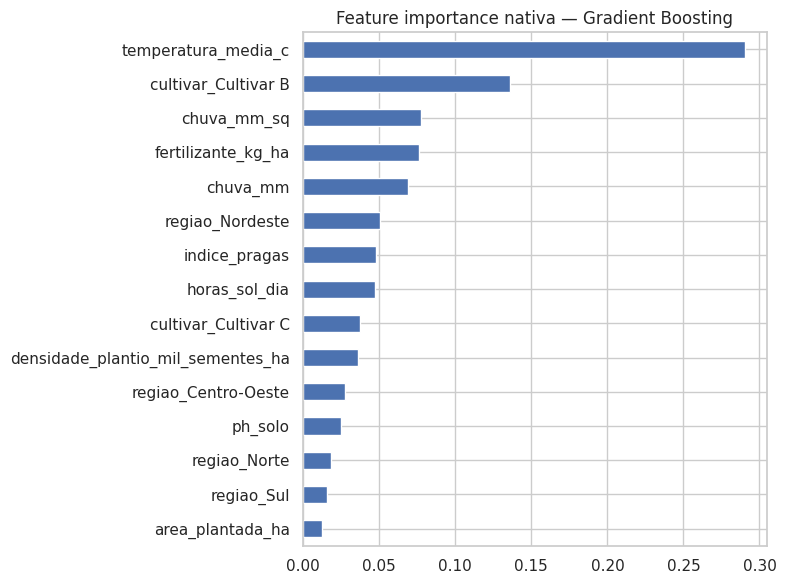

In [ ]:
nomes_features_pos_encoding = (
    features_num
    + list(modelo_final.named_steps["preprocessador"]
           .named_transformers_["cat"].named_steps["onehot"]
           .get_feature_names_out(features_cat))
)

modelo_treinado = modelo_final.named_steps["modelo"]

if hasattr(modelo_treinado, "feature_importances_"):
    importancias = pd.Series(modelo_treinado.feature_importances_, index=nomes_features_pos_encoding)
    importancias.sort_values(ascending=True).tail(15).plot(kind="barh", figsize=(8, 6))
    plt.title(f"Feature importance nativa — {melhor_modelo_nome}")
    plt.tight_layout()
    plt.show()


principal variavel para esse m0delo temperatura media

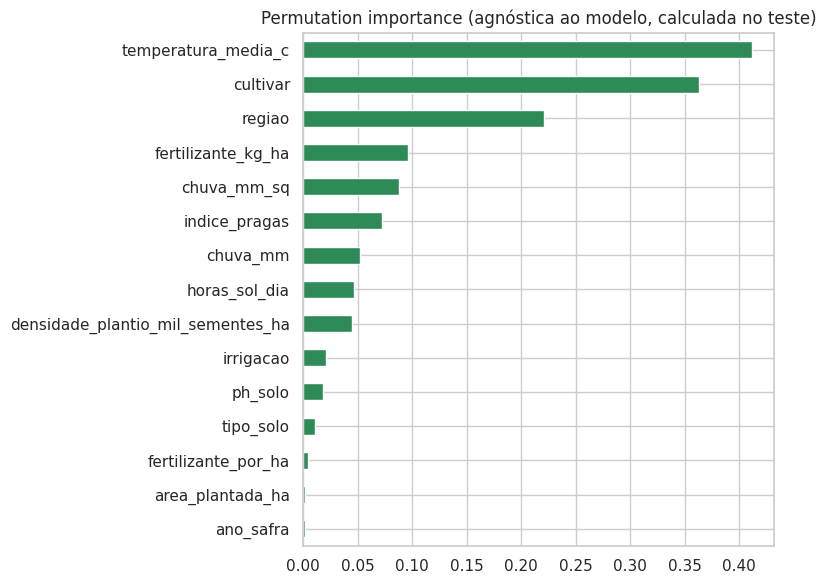

In [ ]:
perm_result = permutation_importance(
    modelo_final, X_test, y_test, scoring="r2", n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)
perm_importances = pd.Series(perm_result.importances_mean, index=features).sort_values()
perm_importances.tail(15).plot(kind="barh", figsize=(8, 6), color="seagreen")
plt.title("Permutation importance (agnóstica ao modelo, calculada no teste)")
plt.tight_layout()
plt.show()


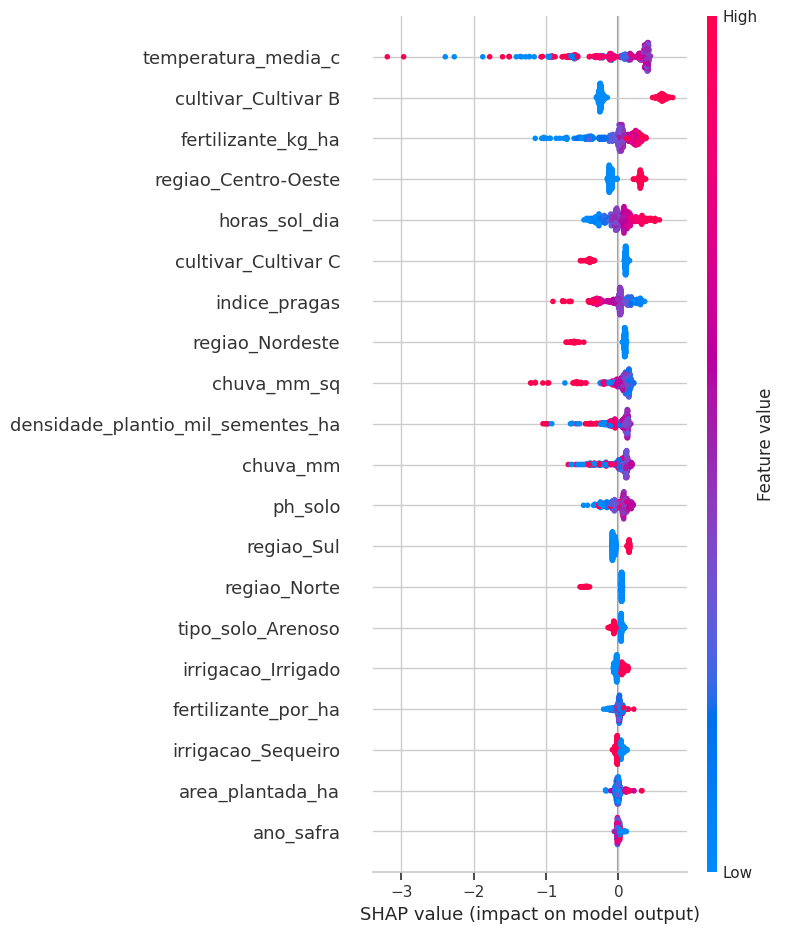

In [ ]:
X_test_transf_arr = modelo_final.named_steps["preprocessador"].transform(X_test)
explainer = shap.TreeExplainer(modelo_treinado)
shap_values = explainer.shap_values(X_test_transf_arr)

shap.summary_plot(shap_values, X_test_transf_arr, feature_names=nomes_features_pos_encoding, show=False)
plt.tight_layout()
plt.show()


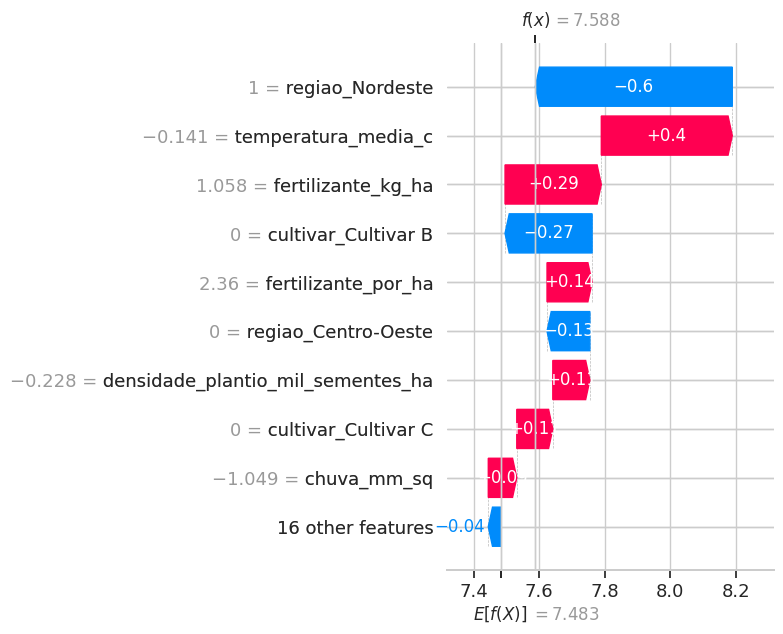

In [ ]:
# Explicação individual (waterfall) para um talhão específico do teste.
# Usamos a API moderna e estável do shap (Explanation), em vez da waterfall_legacy,
# que é uma função interna sujeita a mudar entre versões da biblioteca.
i = 0
shap_explanation = explainer(X_test_transf_arr)
shap_explanation.feature_names = nomes_features_pos_encoding
shap.plots.waterfall(shap_explanation[i], show=False)
plt.tight_layout()
plt.show()


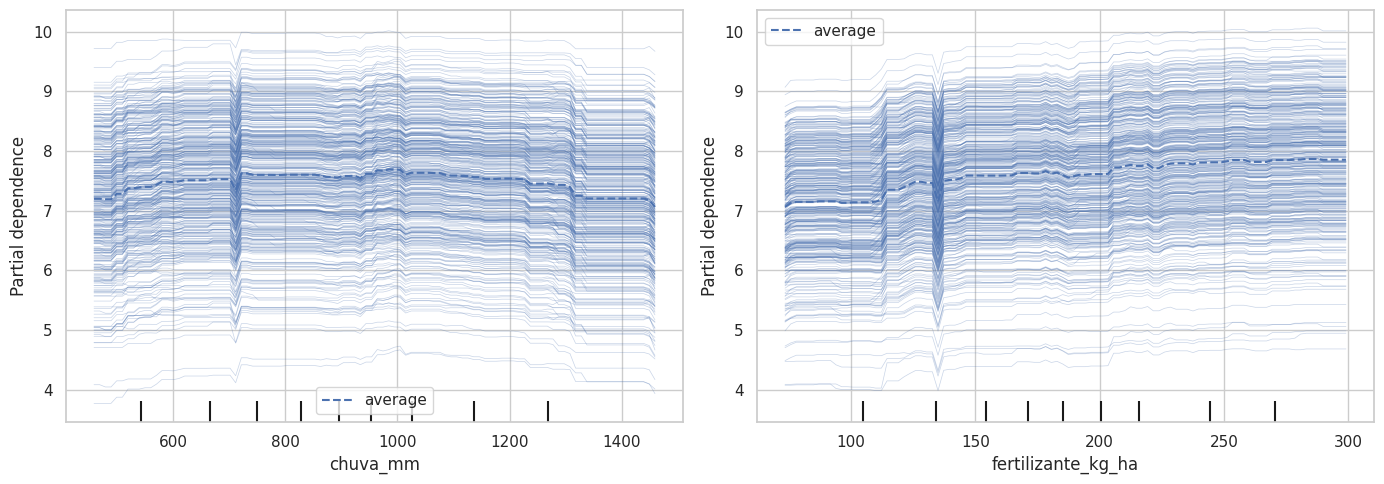

In [ ]:
features_para_pdp = ["chuva_mm", "fertilizante_kg_ha"]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
PartialDependenceDisplay.from_estimator(modelo_final, X_test, features_para_pdp, ax=ax, kind="both")
plt.tight_layout()
plt.show()


**Leitura esperada (validar com um agrônomo real, se possível):** a PDP de `chuva_mm` deveria
mostrar o "ponto ótimo" que simulamos (produtividade sobe até certo volume de chuva e cai depois
disso); a de `fertilizante_kg_ha` deveria mostrar retorno decrescente (ganho grande no início,
efeito marginal cada vez menor). Se alguma feature aparecer com efeito contraintuitivo (ex: mais
praga = mais produtividade), é sinal de alerta — investigue se há vazamento, erro de codificação,
ou se é um padrão genuíno que vale a pena levar a um especialista de domínio antes de confiar nele.


## Da Métrica Técnica ao Valor para o Cliente

R², MAE, RMSE e os gráficos de SHAP são essenciais para comparar modelos entre si e garantir que
o modelo é estatisticamente sólido — mas, sozinhos, não respondem à pergunta que quem decide
(a cooperativa, o financiador, o gestor de operações) realmente faz: **"isso vale a pena usar?"**
Esta seção traduz os resultados técnicos das fases anteriores para linguagem de negócio, para
poder ser apresentada a um público não técnico.


In [ ]:
# Quanto o modelo melhora em relação a não ter modelo nenhum (baseline ingênuo)?
linha_baseline = tabela_resultados[tabela_resultados["modelo"] == "Dummy (média)"].iloc[0]
mae_baseline = linha_baseline["MAE_teste"]
mape_baseline = linha_baseline["MAPE_teste_%"]

reducao_erro_pct = (mae_baseline - mae_f) / mae_baseline * 100

print("SEM MODELO (chute pela média histórica):")
print(f"  erro médio (MAE): {mae_baseline:.2f} ton/ha  |  erro percentual (MAPE): {mape_baseline:.1f}%")
print()
print(f"COM O MODELO ({melhor_modelo_nome}, após tuning):")
print(f"  erro médio (MAE): {mae_f:.2f} ton/ha  |  erro percentual (MAPE): {mape_f:.1f}%")
print()
print(f">>> Redução no erro médio de estimativa: {reducao_erro_pct:.0f}%")


SEM MODELO (chute pela média histórica):
  erro médio (MAE): 0.98 ton/ha  |  erro percentual (MAPE): 13.8%

COM O MODELO (Gradient Boosting, após tuning):
  erro médio (MAE): 0.46 ton/ha  |  erro percentual (MAPE): 6.4%

>>> Redução no erro médio de estimativa: 53%


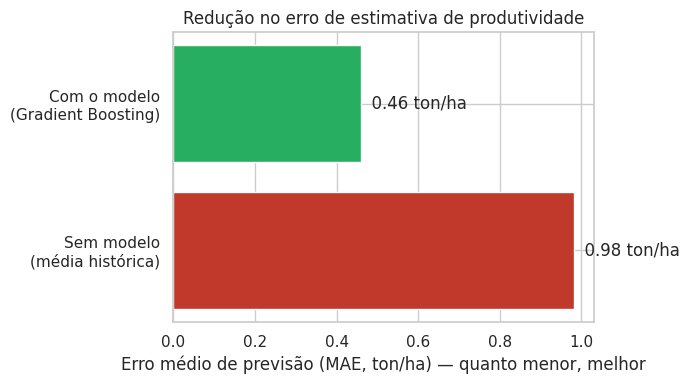

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.barh(
    ["Sem modelo\n(média histórica)", f"Com o modelo\n({melhor_modelo_nome})"],
    [mae_baseline, mae_f],
    color=["#c0392b", "#27ae60"],
)
ax.set_xlabel("Erro médio de previsão (MAE, ton/ha) — quanto menor, melhor")
ax.set_title("Redução no erro de estimativa de produtividade")
for barra, valor in zip(barras, [mae_baseline, mae_f]):
    ax.text(valor, barra.get_y() + barra.get_height() / 2, f"  {valor:.2f} ton/ha", va="center")
plt.tight_layout()
plt.show()


### O que isso significa na prática

- **Antes:** para planejar logística (transporte, armazenagem) ou avaliar risco de crédito por
  talhão, a única referência disponível era a média histórica da região/cultivar — um número que
  ignora completamente as condições daquela safra específica (chuva, solo, manejo).
- **Depois:** o modelo usa as condições reais de cada talhão para dar uma estimativa
  individualizada, reduzindo o erro médio em relação a essa média histórica. Uma estimativa mais
  precisa, aplicada a centenas de talhões, tende a reduzir tanto o excesso de capacidade
  contratada "por precaução" quanto o risco de faltar armazenagem/transporte na safra.

**Recomendações agronômicas priorizadas pela interpretabilidade do modelo** (Fase 10) — validar
com um agrônomo antes de transformar em orientação de manejo:

- Chuva e temperatura têm um "ponto ótimo" claro nos dados — talhões muito acima ou abaixo dele
  perdem produtividade; vale sinalizar isso cedo na safra para quem pode agir (irrigação
  suplementar, por exemplo).
- Fertilizante mostra retorno decrescente: a partir de um certo ponto, aplicar mais fertilizante
  deixa de compensar o custo adicional — o modelo pode ajudar a identificar esse ponto por
  talhão/cultivar em vez de usar uma recomendação genérica.
- Talhões com solo arenoso e sem irrigação são os mais sensíveis a anos de chuva baixa — são os
  primeiros candidatos a priorizar se houver investimento limitado em irrigação.

**Sobre estimar o valor em R$:** como esta base é sintética, não faz sentido calcular uma
economia em reais aqui — seria um número inventado. O caminho real é: (1) validar o modelo com
dados históricos reais da cooperativa, (2) com a área financeira/operacional, definir o custo
unitário de um erro de estimativa (ex: custo de armazenagem contratada e não usada, ou custo de
falta de capacidade), e (3) multiplicar a redução de erro (acima) por esse custo unitário e pelo
número de talhões atendidos por safra. Esse cálculo é o que efetivamente transforma "R² = 0,8x"
em uma cifra que um cliente não técnico entende e pode decidir em cima dela.


## Fase 11 — Persistência e Entregáveis

Fechamos o projeto deixando tudo que é necessário para colocar o modelo em uso: o pipeline
completo (pré-processamento + modelo), a lista de features, as métricas finais documentadas e um
script de inferência pronto para novos dados (`predict.py`, na raiz do projeto).


In [ ]:
# Mesma lógica de resolução de caminho da Fase 1: se existir a estrutura de
# pastas do projeto completo (pasta pai com data/, models/ etc.), salvamos lá;
# caso contrário (ex: notebook rodando sozinho no Colab), salvamos ao lado do
# próprio notebook.
BASE_DIR = ".." if os.path.isdir("../data") else "."
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

bundle = {
    "pipeline": modelo_final,
    "features": features,
    "features_num": features_num,
    "features_cat": features_cat,
    "modelo_nome": melhor_modelo_nome,
    "metricas_teste": {"R2": r2_f, "MAE": mae_f, "RMSE": rmse_f, "MAPE_%": mape_f},
    "melhores_parametros": busca.best_params_,
}
MODELO_PATH = os.path.join(MODELS_DIR, "modelo_produtividade_safra.joblib")
joblib.dump(bundle, MODELO_PATH)
print(f"Modelo salvo em {MODELO_PATH}")


Modelo salvo em ./models/modelo_produtividade_safra.joblib


In [ ]:
relatorio_final = f"""
RELATORIO FINAL — Modelo de Previsão de Produtividade de Safra
================================================================
Modelo final: {melhor_modelo_nome} (com tuning via RandomizedSearchCV)

Métricas no conjunto de teste (20% dos dados, nunca visto no treino):
  R²   = {r2_f:.4f}
  MAE  = {mae_f:.4f} ton/ha
  RMSE = {rmse_f:.4f} ton/ha
  MAPE = {mape_f:.2f}%

Intervalo de confiança (bootstrap, 95%):
  R²  em [{np.percentile(r2_boot, 2.5):.4f}, {np.percentile(r2_boot, 97.5):.4f}]
  MAE em [{np.percentile(mae_boot, 2.5):.4f}, {np.percentile(mae_boot, 97.5):.4f}] ton/ha

Limitações e premissas:
  - Modelo treinado em dados sintéticos de um cenário fictício; validar com dados reais
    da cooperativa antes de qualquer uso operacional.
  - Não validado para valores de features fora do range observado no treino
    (ex: chuva muito acima de {X_train['chuva_mm'].max():.0f}mm).
  - `ano_safra` foi tratado como covariável transversal, não como dimensão temporal de
    forecasting — não usar este modelo para prever tendências futuras ano a ano.

Próximos passos recomendados:
  - Coletar `indice_pragas` de forma mais consistente em talhões pequenos (hoje é o
    principal gerador de nulos MNAR).
  - Reavaliar o modelo a cada nova safra para detectar drift (mudança na relação
    clima/manejo x produtividade ao longo do tempo).
  - Validar as leituras de PDP/SHAP com um agrônomo antes de usar o modelo para
    recomendações de manejo.
"""

print(relatorio_final)
RELATORIO_PATH = os.path.join(BASE_DIR, "relatorio_executivo.txt")
with open(RELATORIO_PATH, "w", encoding="utf-8") as f:
    f.write(relatorio_final)
print(f"\nRelatorio salvo em {RELATORIO_PATH}")



RELATORIO FINAL — Modelo de Previsão de Produtividade de Safra
Modelo final: Gradient Boosting (com tuning via RandomizedSearchCV)

Métricas no conjunto de teste (20% dos dados, nunca visto no treino):
  R²   = 0.7841
  MAE  = 0.4591 ton/ha
  RMSE = 0.5701 ton/ha
  MAPE = 6.42%

Intervalo de confiança (bootstrap, 95%):
  R²  em [0.7426, 0.8163]
  MAE em [0.4263, 0.4927] ton/ha

Limitações e premissas:
  - Modelo treinado em dados sintéticos de um cenário fictício; validar com dados reais
    da cooperativa antes de qualquer uso operacional.
  - Não validado para valores de features fora do range observado no treino
    (ex: chuva muito acima de 1687mm).
  - `ano_safra` foi tratado como covariável transversal, não como dimensão temporal de
    forecasting — não usar este modelo para prever tendências futuras ano a ano.

Próximos passos recomendados:
  - Coletar `indice_pragas` de forma mais consistente em talhões pequenos (hoje é o
    principal gerador de nulos MNAR).
  - Reavaliar o 

### Checklist de entregáveis

- [x] Modelo final + pipeline de pré-processamento salvos (`models/modelo_produtividade_safra.joblib`)
- [x] Lista de features e ordem salvas dentro do mesmo bundle
- [x] Métricas finais documentadas (`relatorio_executivo.txt`)
- [x] `requirements.txt` com as dependências
- [x] Script de inferência para produção (`predict.py`, na raiz do projeto)
- [x] Este notebook, com todo o histórico de decisões (log de decisões na Fase 2)

## Conclusão e próximos passos

O pipeline cobriu as 11 fases: da inspeção inicial ao modelo salvo e pronto para uso. O próximo
passo natural é validar este fluxo com dados reais da cooperativa (esta base é sintética) e, uma
vez validado, decidir a cadência de retraining e o formato de entrega das previsões (API, arquivo
batch, dashboard). Fico à disposição para aprofundar qualquer fase — por exemplo, testar outros
modelos de boosting (XGBoost/LightGBM/CatBoost) se houver preferência ou restrição de
infraestrutura específica.
